<>:67: SyntaxWarning: invalid escape sequence '\A'
<>:67: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_643663/2388834567.py:67: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Observed Wavelength ($\AA$)', fontsize=12)


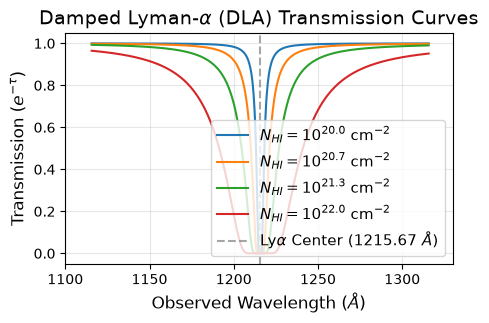

Plot generated successfully.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import wofz

# Constants for Lyman-alpha transition
lambda_0 = 1215.67  # Angstroms
c = 2.99792458e18   # Speed of light in Angstroms/s
f_12 = 0.4164       # Oscillator strength for Ly-alpha
Gamma_21 = 6.265e8  # Einstein A coefficient / damping constant in s^-1

# Atomic constants for cross-section normalization
# sigma_0 = (pi * e^2) / (m_e * c) * f_12
# In standard CGS units: e = 4.8032e-10 esu, m_e = 9.10938e-28 g, c = 2.99792e10 cm/s
# Pre-factor for cross section in cm^2 * Hz:
# (pi * e^2) / (m_e * c) = 0.02654 cm^2 Hz
sigma_data_prefactor = 0.02654 * f_12 

def voigt_profile(delta_lam, T=10000.0):
    """
    Computes the cross section sigma(lambda) in cm^2 using the Voigt profile.
    delta_lam: array of wavelength shifts from line center in Angstroms
    T: Temperature in Kelvin (for Doppler broadening)
    """
    # Thermal velocity (Doppler parameter b)
    k_B = 1.380649e-16 # erg/K
    m_H = 1.6735575e-24 # g
    b = np.sqrt(2 * k_B * T / m_H) * 1e8 # in Angstrom/s (multiply cm/s by 1e8 to get A/s? No, v is cm/s, delta_nu is in Hz)
    
    # Let's do frequencies to be completely safe
    # nu = c / lambda
    lam = lambda_0 + delta_lam
    nu = c / lam
    nu_0 = c / lambda_0
    
    # Doppler width in Hz
    v_th = np.sqrt(2 * k_B * T / m_H) # cm/s
    del_nu_D = (v_th / 2.99792458e10) * nu_0
    
    # Dimensionless variables for scipy's wofz (Faddeeva function)
    x = (nu - nu_0) / del_nu_D
    y = Gamma_21 / (4 * np.pi * del_nu_D)
    
    # Voigt profile function normalized in frequency
    phi = wofz(x + 1j*y).real / (np.sqrt(np.pi) * del_nu_D)
    
    # Cross section in cm^2
    sigma = sigma_data_prefactor * phi
    return sigma

# Wavelength array around Ly-alpha line center
delta_wavelengths = np.linspace(-100, 100, 1000) # -100 to +100 Angstroms
wavelengths = lambda_0 + delta_wavelengths

# Column densities to plot (typical DLA values: log N >= 20.3)
N_list = [1e20, 5e20, 2e21, 1e22]

plt.figure(figsize=(5, 3))

for N in N_list:
    sigma = voigt_profile(delta_wavelengths, T=10000.0)
    tau = N * sigma
    transmission = np.exp(-tau)
    plt.plot(wavelengths, transmission, label=f'$N_{{HI}} = 10^{{{np.log10(N):.1f}}}$ cm$^{{-2}}$')

plt.axvline(lambda_0, color='gray', linestyle='--', alpha=0.7, label=r'Ly$\alpha$ Center ($1215.67\ \AA$)')
plt.title(r'Damped Lyman-$\alpha$ (DLA) Transmission Curves', fontsize=14)
plt.xlabel('Observed Wavelength ($\AA$)', fontsize=12)
plt.ylabel('Transmission ($e^{-\\tau}$)', fontsize=12)
plt.xlim(1100, 1330)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='lower right')
plt.show()
plt.close()
print("Plot generated successfully.")

In [1]:
import numpy as np
from scipy.special import wofz
from astropy.table import Table

wv = []
temp = Table.read('/home/caltech-msanche3/hot-templates/fsps-hot/45k/fsps_45k_t0.5_Av0.5.fits')
for i in range(len(temp)):
    wv.append(temp[i]['wave'].item())

# 1. Paste your full wavelength array here (in Angstroms)
wavelengths = np.array(wv)

# 2. Define DLA Physical Constants (Lyman-alpha transition)
lambda_0 = 1215.67  # Rest-frame center in Angstroms
c = 2.99792458e18   # Speed of light in Angstroms/s
f_12 = 0.4164       # Oscillator strength
Gamma_21 = 6.265e8  # Damping constant in s^-1
sigma_0_prefactor = 0.02654 * f_12 

def compute_dla_transmission(wave_grid, log_NHI, T=10000.0):
    """
    Computes DLA transmission values for an arbitrary wavelength grid.
    wave_grid: np.ndarray of wavelengths in Angstroms
    log_NHI: log10 of the HI column density (cm^-2)
    T: Gas temperature in Kelvin
    """
    N_HI = 10**log_NHI
    
    # Map wavelengths to frequencies (Hz)
    nu = c / wave_grid
    nu_0 = c / lambda_0
    
    # Thermal Doppler broadening parameter
    k_B = 1.380649e-16  # erg/K
    m_H = 1.6735575e-24 # grams
    v_th = np.sqrt(2 * k_B * T / m_H)
    del_nu_D = (v_th / 2.99792458e10) * nu_0
    
    # Voigt Profile dimensionless line-shifts
    x = (nu - nu_0) / del_nu_D
    y = Gamma_21 / (4 * np.pi * del_nu_D)
    
    # Evaluate Voigt profile using Faddeeva function
    phi = wofz(x + 1j*y).real / (np.sqrt(np.pi) * del_nu_D)
    
    # Calculate cross-section, optical depth, and transmission
    sigma = sigma_0_prefactor * phi
    tau = N_HI * sigma
    transmission = np.exp(-tau)
    
    return transmission

# 3. Generate your transmission array
# You can tweak log_NHI depending on your system's column density
transmission_list = compute_dla_transmission(wavelengths, log_NHI=20.5, T=10000.0)

# 4. Now you can multiply this directly with your flux!
#plt.plot(wavelengths[130:280],transmission_list[130:280])
new_flux = temp['flux'] * transmission_list
new_continuum = temp['continuum'] * transmission_list
new_dered = temp['dered']*transmission_list

# Combine them as columns
import numpy as np
from astropy.io import fits

# 2. Define each column with a name, format, and array
# Formats: 'K' = 64-bit int, 'D' = double float, 'A' = character string
col1 = fits.Column(name='wave', format='D', array=np.array(wavelengths))
col2 = fits.Column(name='flux', format='D',array=np.array(new_flux))
col3 = fits.Column(name='continuum', format='D',array=np.array(new_continuum))
col4 = fits.Column(name='dered', format='D', array=np.array(new_dered))

# 3. Combine columns into a table
col_defs = fits.ColDefs([col1, col2, col3, col4])
table_hdu = fits.BinTableHDU.from_columns(col_defs)

# 4. Write the table to a FITS file
table_hdu.writeto('fsps_45k_t0.5_Av0.5.mod.fits', overwrite=True)

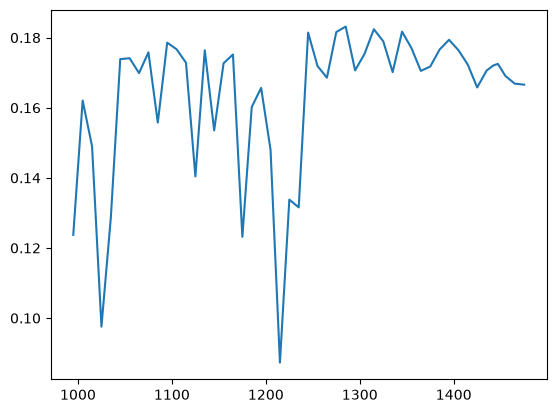

In [4]:
plt.plot(temp['wave'][130:280],temp['continuum'][130:280])
#plt.plot(temp['wave'][130:280],new_continuum[130:280])
#plt.plot(temp['wave'][130:280],new_flux[130:280])

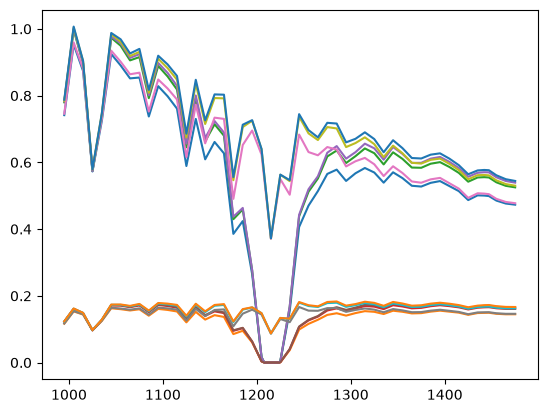

In [ ]:
old_0 = Table.read('/home/caltech-msanche3/hot-templates/fsps-hot/45k/fsps_45k_t0.1_Av0.0.fits')
old_1 = Table.read('/home/caltech-msanche3/hot-templates/fsps-hot/45k/fsps_45k_t0.1_Av0.5.fits')
old_2 = Table.read('/home/caltech-msanche3/hot-templates/fsps-hot/45k/fsps_45k_t0.3_Av0.0.fits')
old_3 = Table.read('/home/caltech-msanche3/hot-templates/fsps-hot/45k/fsps_45k_t0.3_Av0.5.fits')
old_4 = Table.read('/home/caltech-msanche3/hot-templates/fsps-hot/45k/fsps_45k_t0.5_Av0.0.fits')
old_5 = Table.read('/home/caltech-msanche3/hot-templates/fsps-hot/45k/fsps_45k_t0.5_Av0.5.fits')

new_0 = Table.read('/home/caltech-msanche3/SURF2026/scripts/fsps_45k_t0.1_Av0.0.mod.fits')
new_1 = Table.read('/home/caltech-msanche3/SURF2026/scripts/fsps_45k_t0.1_Av0.5.mod.fits')
new_2 = Table.read('/home/caltech-msanche3/SURF2026/scripts/fsps_45k_t0.3_Av0.0.mod.fits')
new_3 = Table.read('/home/caltech-msanche3/SURF2026/scripts/fsps_45k_t0.3_Av0.5.mod.fits')
new_4 = Table.read('/home/caltech-msanche3/SURF2026/scripts/fsps_45k_t0.5_Av0.0.mod.fits')
new_5 = Table.read('/home/caltech-msanche3/SURF2026/scripts/fsps_45k_t0.5_Av0.5.mod.fits')

plt.plot(new_0['wave'][130:280],new_0['continuum'][130:280])
plt.plot(new_1['wave'][130:280],new_1['continuum'][130:280])
plt.plot(new_2['wave'][130:280],new_2['continuum'][130:280])
plt.plot(new_3['wave'][130:280],new_3['continuum'][130:280])
plt.plot(new_4['wave'][130:280],new_4['continuum'][130:280])
plt.plot(new_5['wave'][130:280],new_5['continuum'][130:280])


plt.plot(old_0['wave'][130:280],old_0['continuum'][130:280])
plt.plot(old_1['wave'][130:280],old_1['continuum'][130:280])
plt.plot(old_2['wave'][130:280],old_2['continuum'][130:280])
plt.plot(old_3['wave'][130:280],old_3['continuum'][130:280])
plt.plot(old_4['wave'][130:280],old_4['continuum'][130:280])
plt.plot(old_5['wave'][130:280],old_5['continuum'][130:280])

In [11]:
from astropy.table import Table, vstack
params = Table.read('/home/caltech-msanche3/hot-templates/fsps-hot/45k/fsps_45k.param.fits')
arr = np.array(params['mass', 'formed_mass', 'sfr', 'energy_abs', 'rline [OII]3726', 'rline [OII]3729', 'LHb', 'rline [OIII]4960', 'rline [OIII]5007', 'LHa', 'rline [NII]6549', 'rline [NII]6585', 'rline Pabeta12819', 'rline Paalpha18752', 'line [CII]157.7m', 'dust_index', 'Av', 'gas_logu', 'logzsol', 'imf_type', 'zred', 'lwAgeV', 'mwAge', 'lwAgeR', 'Lu', 'Lv', 'Lj', 'Lk', 'L1400', 'L2800', 'LOIII', 'LOII', 'LHaNII', 'LIR'])
duplicated_table = vstack([params, params])

# should i be changing the length of the column or will this mess things up?
duplicated_table['file'] = duplicated_table['file'].astype('U30')

duplicated_table['file'][0]='fsps_45k_mod_t0.1_Av0.0'
duplicated_table['file'][1]='fsps_45k_mod_t0.1_Av0.5'
duplicated_table['file'][2]='fsps_45k_mod_t0.3_Av0.0'
duplicated_table['file'][3]='fsps_45k_mod_t0.3_Av0.5'
duplicated_table['file'][4]='fsps_45k_mod_t0.5_Av0.0'
duplicated_table['file'][5]='fsps_45k_mod_t0.5_Av0.5'
duplicated_table['file'][6]='fsps_45k_mod_t0.1_Av0.0.mod.22'
duplicated_table['file'][7]='fsps_45k_mod_t0.1_Av0.5.mod.22'
duplicated_table['file'][8]='fsps_45k_mod_t0.3_Av0.0.mod.22'
duplicated_table['file'][9]='fsps_45k_mod_t0.3_Av0.5.mod.22'
duplicated_table['file'][10]='fsps_45k_mod_t0.5_Av0.0.mod.22'
duplicated_table['file'][11]='fsps_45k_mod_t0.5_Av0.5.mod.22'
print(len(duplicated_table))
print(duplicated_table)

duplicated_table.write('fsps_45k_mod.param.fits', format='fits', overwrite=True)


12
             file              ...                   LIR                   
------------------------------ ... ----------------------------------------
       fsps_45k_mod_t0.1_Av0.0 ... 10.769909898717742 .. 10.769909898717742
       fsps_45k_mod_t0.1_Av0.5 ...   646.6964897537998 .. 646.6964897537998
       fsps_45k_mod_t0.3_Av0.0 ... 11.951491255638757 .. 11.951491255638757
       fsps_45k_mod_t0.3_Av0.5 ...     681.453734863923 .. 681.453734863923
       fsps_45k_mod_t0.5_Av0.0 ... 12.346932657249909 .. 12.346932657249909
       fsps_45k_mod_t0.5_Av0.5 ...   746.5386842191946 .. 746.5386842191946
fsps_45k_mod_t0.1_Av0.0.mod.22 ... 10.769909898717742 .. 10.769909898717742
fsps_45k_mod_t0.1_Av0.5.mod.22 ...   646.6964897537998 .. 646.6964897537998
fsps_45k_mod_t0.3_Av0.0.mod.22 ... 11.951491255638757 .. 11.951491255638757
fsps_45k_mod_t0.3_Av0.5.mod.22 ...     681.453734863923 .. 681.453734863923
fsps_45k_mod_t0.5_Av0.0.mod.22 ... 12.346932657249909 .. 12.346932657249909
fsps_45k_

In [13]:
tbl = Table.read('/home/caltech-msanche3/SURF2026/scripts/fsps_45k_mod.param.fits')
print(tbl)

             file              ...                   LIR                   
------------------------------ ... ----------------------------------------
       fsps_45k_mod_t0.1_Av0.0 ... 10.769909898717742 .. 10.769909898717742
       fsps_45k_mod_t0.1_Av0.5 ...   646.6964897537998 .. 646.6964897537998
       fsps_45k_mod_t0.3_Av0.0 ... 11.951491255638757 .. 11.951491255638757
       fsps_45k_mod_t0.3_Av0.5 ...     681.453734863923 .. 681.453734863923
       fsps_45k_mod_t0.5_Av0.0 ... 12.346932657249909 .. 12.346932657249909
       fsps_45k_mod_t0.5_Av0.5 ...   746.5386842191946 .. 746.5386842191946
fsps_45k_mod_t0.1_Av0.0.mod.22 ... 10.769909898717742 .. 10.769909898717742
fsps_45k_mod_t0.1_Av0.5.mod.22 ...   646.6964897537998 .. 646.6964897537998
fsps_45k_mod_t0.3_Av0.0.mod.22 ... 11.951491255638757 .. 11.951491255638757
fsps_45k_mod_t0.3_Av0.5.mod.22 ...     681.453734863923 .. 681.453734863923
fsps_45k_mod_t0.5_Av0.0.mod.22 ... 12.346932657249909 .. 12.346932657249909
fsps_45k_mod